In [15]:
import xgboost as xgb
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, roc_curve, auc
import xgboost as xgb 
from sklearn import svm
from sklearn.ensemble import RandomForestClassifier
from src.processing import Processing
import config
from sklearn.feature_selection import SelectKBest, chi2
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import pandas as pd
import numpy as np
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
import warnings
from src.datasplitting import DataSplitting
warnings.filterwarnings('ignore')
from sklearn.model_selection import GridSearchCV, PredefinedSplit, TimeSeriesSplit
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    confusion_matrix, roc_auc_score, precision_recall_curve, auc, classification_report
)
from src.processing import Processing
from sklearn.metrics import roc_curve, precision_recall_curve, average_precision_score
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier
from imblearn.under_sampling import EditedNearestNeighbours
from imblearn.pipeline import make_pipeline, Pipeline
from sklearn.preprocessing import StandardScaler
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xgboost as xgb
from imblearn.over_sampling import SMOTE
from collections import Counter
from src.balance import split_data_nested_cv_ts, split_data, drop_mice_group, balance_classes_by_undersampling, balance_classes_by_undersampling_features_and_target, balance_before_merge, oversample_and_merge, ensemble_sample_and_merge

In [16]:
N_SPLITS = 4
TEST_SIZE = 0.6
SEED = 42
SAMPLE_SIZE = 10
TOP_FEATURES = 15

# Hyperparameter grid for XGBClassifier
PARAM_GRID = {
    'xgbclassifier__n_estimators': [100, 500, 1000],
    'xgbclassifier__learning_rate': [0.01, 0.05, 0.1],
    'xgbclassifier__max_depth': [3, 4, 5, 7],
    'xgbclassifier__subsample': [0.6, 0.7, 0.8, 1.0],
    'xgbclassifier__min_child_weight': [1, 5, 10],
    'xgbclassifier__gamma': [0.5, 1, 1.5, 2, 5],
    'xgbclassifier__colsample_bytree': [0.6, 0.8, 1.0]
}


In [ ]:
def train_test_and_show_results(split_method: str, m_data: dict, tune_hyperparameters: bool = False, param_grid: dict = None, xgb_params: dict = None, show_label: bool = True):

    # Track results for each fold
    fold_accuracies, fold_f1_macros, fold_precisions, fold_recalls, fold_roc_aucs, fold_f1_micros, fold_f1_weighted, feature_importances = [], [], [], [], [], [], [], []
    class_metrics = {'true_positives': [], 'false_negatives': [], 'false_positives': [], 'true_negatives': []}

    best_params_per_fold = []  # Track best parameters per fold

    # Store ROC curve points for all folds
    roc_curves = []

    split_0_data = next(iter(m_data.values()))

    feature_names = split_0_data['X_train'].columns  # This will be a pandas.Index
    feature_names = feature_names.str.replace('original_', '', regex=False)

    for fold, split_data in m_data.items():
        print(f"\nFold {fold}:")
        print(f"Original train class distribution: {Counter(split_data['y_train'])}")
        print(f"Original test class distribution: {Counter(split_data['y_test'])}")

        if tune_hyperparameters:

            # Define the model with hyperparameter tuning
            model = Pipeline([
                ('scaler', StandardScaler()), 
                ('smote', SMOTE(k_neighbors=5, random_state=SEED)),
                ('xgbclassifier', xgb.XGBClassifier(random_state=SEED)),
            ])

            grid_search = GridSearchCV(model, param_grid=param_grid, cv=TimeSeriesSplit(n_splits=5), scoring='f1_macro', n_jobs=-1)
            grid_search.fit(split_data['X_train'], split_data['y_train'])
            best_model = grid_search.best_estimator_
            best_params = grid_search.best_params_
            best_params_per_fold.append(best_params)  # Save best parameters
            print(f"Best parameters for fold {fold}: {best_params}")
        else:
            # Use provided xgb_params or default parameters if not tuning
            model = Pipeline([
                ('scaler', StandardScaler()), 
                ('smote', SMOTE(k_neighbors=5, random_state=SEED)),
                ('xgbclassifier', xgb.XGBClassifier(**(xgb_params or {}), random_state=SEED)),
            ])
            
            model.fit(split_data['X_train'], split_data['y_train'])
            best_model = model        

        # Extract feature importances from XGBoost
        xgb_model = best_model.named_steps['xgbclassifier']
        importances = xgb_model.feature_importances_

        # Evaluate on the test set
        preds = best_model.predict(split_data['X_test'])
        preds_proba = best_model.predict_proba(split_data['X_test'])[:, 1]  # Probability for the positive class
        
        # Calculate metrics
        accuracy = accuracy_score(split_data['y_test'], preds)
        f1_macro = f1_score(split_data['y_test'], preds, average='macro')
        f1_micro = f1_score(split_data['y_test'], preds, average='micro')
        f1_weighted = f1_score(split_data['y_test'], preds, average='weighted')
        precision = precision_score(split_data['y_test'], preds)
        recall = recall_score(split_data['y_test'], preds)

        fpr, tpr, _ = roc_curve(split_data['y_test'], preds_proba, pos_label=1)
        roc_auc = auc(fpr, tpr)

        # If auc is NaN, set to 0
        if np.isnan(roc_auc):
            roc_auc = 0
        
        roc_curves.append((fpr, tpr))

        # Calculate the confusion matrix
        cm = confusion_matrix(split_data['y_test'], preds)

        # Handle cases where the confusion matrix shape is unexpected
        if cm.shape == (1, 1):  # Only one class present
            tn, fp, fn, tp = (cm[0, 0], 0, 0, 0) if split_data['y_test'].iloc[0] == 0 else (0, 0, 0, cm[0, 0])
        elif cm.shape == (1, 2):  # One class is missing in y_test
            tn, fp, fn, tp = (cm[0, 0], cm[0, 1], 0, 0)
        elif cm.shape == (2, 1):  # One class is missing in preds
            tn, fp, fn, tp = (0, 0, cm[1, 0], cm[0, 0])
        else:  # Normal case with both classes present
            tn  , fp, fn, tp = cm.ravel()

        # Print fold results
        print(f"\n\nFold {fold} results:")
        print(f"Accuracy: {accuracy:.4f}")
        print(f"F1-macro: {f1_macro:.4f}")
        print(f"F1-micro: {f1_micro:.4f}")
        print(f"F1-weighted: {f1_weighted:.4f}")
        print(f"Precision: {precision:.4f}")
        print(f"Recall: {recall:.4f}")
        print(f"ROC AUC: {roc_auc:.4f}")
        print(f"True Positives: {tp}, False Negatives: {fn}, False Positives: {fp}, True Negatives: {tn}")
        print(f"Classification report:\n{classification_report(split_data['y_test'], preds)}")
        
        # Identify misclassified instances
        misclassified = split_data['X_test'][split_data['y_test'] != preds]
        misclassified['true_label'] = split_data['y_test'][split_data['y_test'] != preds]
        misclassified['predicted_label'] = preds[split_data['y_test'] != preds]

        # Add m_id and day_of_study back for analysis
        misclassified['m_id'] = split_data['X_test']['m_id']
        misclassified['day_of_study'] = split_data['X_test']['day_of_study']

        # Save misclassified instances for this fold
        misclassified.to_csv(f"misclassified_fold_{fold}.csv", index=False)

        print(f"Misclassified instances in fold {fold}:")
        print(misclassified[['m_id', 'day_of_study', 'true_label', 'predicted_label']].head())

        print("-" * 50)
        
        # Plot top k features for this fold
        # top_indices = np.argsort(importances)[-TOP_FEATURES:][::-1]
        # top_importances = importances[top_indices]

        # plt.figure(figsize=(10, 3))
        # plt.subplot(1, 2, 1)
        # plt.barh(range(TOP_FEATURES), top_importances, color='skyblue', align='center')
        # plt.yticks(range(TOP_FEATURES), feature_names[top_indices], ha="right")
        # plt.ylabel("Feature Index")
        # plt.xlabel("Importance")
        # plt.title(f"Top {TOP_FEATURES} Feature Importances (Fold {fold})")
        # # Plot confusion matrix
        # plt.subplot(1, 2, 2)
        # cm = confusion_matrix(split_data['y_test'], preds)
        # sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
        # plt.title(f'Confusion Matrix (Fold {fold})')
        # plt.xlabel('Predicted Label')
        # plt.ylabel('True Label')
        # plt.tight_layout()
        # plt.show()

        # Track results
        fold_accuracies.append(accuracy)
        fold_f1_macros.append(f1_macro)
        fold_f1_micros.append(f1_micro)
        fold_f1_weighted.append(f1_weighted)
        fold_precisions.append(precision)
        fold_recalls.append(recall)
        fold_roc_aucs.append(roc_auc)
        feature_importances.append(importances)

        class_metrics['true_positives'].append(tp)
        class_metrics['false_negatives'].append(fn)
        class_metrics['false_positives'].append(fp)
        class_metrics['true_negatives'].append(tn)

    print(f"\nAll Folds Completed.")
    print("\n--------------------------------------------------")
    print("\nSummary of Results:\n")

    # Display best parameters summary
    if tune_hyperparameters:
        print("\nBest parameters per fold:")
        for fold, params in enumerate(best_params_per_fold):
            print(f"Fold {fold}: {params}")

    # Plotting ROC and Precision-Recall curves side by side
    plt.figure(figsize=(15, 5))

    # ROC Curve Plot
    plt.subplot(1, 2, 1)  # First plot (1 row, 2 columns, 1st plot)
    if show_label:
        for i, (fpr, tpr) in enumerate(roc_curves):
            plt.plot(fpr, tpr, label=f'Fold {i} (ROC AUC = {fold_roc_aucs[i]:.2f})')
    else:
        for i, (fpr, tpr) in enumerate(roc_curves):
            plt.plot(fpr, tpr)
    plt.plot([0, 1], [0, 1], 'k--', label="Random Classifier")
    plt.title("ROC Curve Across Folds")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.legend(loc="lower right")

    # Calculate mean importances across folds
    mean_importances = np.mean(feature_importances, axis=0)
    # Get indices of the top k features by mean
    top_indices_mean = np.argsort(mean_importances)[-TOP_FEATURES:][::-1]
    top_importances_mean = mean_importances[top_indices_mean]

    plt.subplot(1, 2, 2)  # Second plot (1 row, 2 columns, 2nd plot)
    plt.barh(range(TOP_FEATURES), top_importances_mean, color='skyblue', align='center')
    plt.yticks(range(TOP_FEATURES), feature_names[top_indices_mean])
    plt.ylabel("Feature Index")
    plt.xlabel("Importance")
    plt.title(f"Top {TOP_FEATURES} Feature Importances (Mean)")

    # Display the plots side by side
    plt.tight_layout()  # Adjust layout for better spacing
    plt.show()

    # Display summary statistics across folds
    print(f"\nSummary Across Folds:")
    print(f"Mean accuracy: {np.mean(fold_accuracies):.4f}")
    print(f"Mean F1-macro: {np.mean(fold_f1_macros):.4f}")
    print(f"Mean F1-micro: {np.mean(fold_f1_micros):.4f}")
    print(f"Mean F1-weighted: {np.mean(fold_f1_weighted):.4f}")
    print(f"Mean precision: {np.mean(fold_precisions):.4f}")
    print(f"Mean recall: {np.mean(fold_recalls):.4f}")
    print(f"Mean ROC AUC: {np.mean(fold_roc_aucs):.4f}")

    # Save top feature importances and split method in a txt file
    with open('top_features.txt', 'a') as f:
        f.write(f"\nSplit Method: {split_method}\n")
        f.write("Top Feature Importances:\n")
        for i, idx in enumerate(top_indices_mean):
            f.write(f"{i+1}. {feature_names[idx]}: {top_importances_mean[i]}\n")

    # Optional: Calculate the most common parameters across folds
    if tune_hyperparameters:
        most_comon_params = max(set(best_params_per_fold), key=best_params_per_fold.count)
        print("\nMost common parameters across folds:")
        print(most_comon_params)

In [18]:
# Step 1: Load and preprocess the data
dataclass = Processing(source_path=config.RADIOMICS_FINAL_FEATURES, all_features=False)
dataclass.read()
# df = dataclass.preprocess()  # Assume this keeps mouse IDs for splitting
df = dataclass.df

In [19]:
split_method, m_data = DataSplitting.expanding_window_split(df, 4)

#train_test_and_show_results(m_data, tune_hyperparameters=True, param_grid=PARAM_GRID)
train_test_and_show_results(split_method=split_method, m_data=m_data, tune_hyperparameters=False, xgb_params= {'xgbclassifier__colsample_bytree': 0.6, 'xgbclassifier__gamma': 0.5,
 'xgbclassifier__learning_rate': 0.01,
 'xgbclassifier__max_depth': 3,
 'xgbclassifier__min_child_weight': 1,
 'xgbclassifier__n_estimators': 100,
 'xgbclassifier__subsample': 0.6
})


Fold 0:
Original train class distribution: Counter({0: 64, 1: 14})
Original test class distribution: Counter({0: 61, 1: 15})


Fold 0 results:
Accuracy: 0.8158
F1-macro: 0.5589
F1-micro: 0.8158
F1-weighted: 0.7626
Precision: 0.6667
Recall: 0.1333
ROC AUC: 0.7202
True Positives: 2, False Negatives: 13, False Positives: 1, True Negatives: 60
Classification report:
              precision    recall  f1-score   support

           0       0.82      0.98      0.90        61
           1       0.67      0.13      0.22        15

    accuracy                           0.82        76
   macro avg       0.74      0.56      0.56        76
weighted avg       0.79      0.82      0.76        76



KeyError: 'm_id'

In [ ]:
xgb_params = {
 'xgbclassifier__colsample_bytree': 0.6,
 'xgbclassifier__gamma': 0.5,
 'xgbclassifier__learning_rate': 0.01,
 'xgbclassifier__max_depth': 3,
 'xgbclassifier__min_child_weight': 1,
 'xgbclassifier__n_estimators': 100,
 'xgbclassifier__subsample': 0.6
}

Total groups: 18, Test groups: 10

Fold 0:
Original train class distribution: Counter({0: 234, 1: 52})
Original test class distribution: Counter({0: 82, 1: 14})


Fold 0 results:
Accuracy: 0.8438
F1-macro: 0.5619
F1-micro: 0.8438
F1-weighted: 0.8108
Precision: 0.4000
Recall: 0.1429
ROC AUC: 0.8145
True Positives: 2, False Negatives: 12, False Positives: 3, True Negatives: 79
Classification report:
              precision    recall  f1-score   support

           0       0.87      0.96      0.91        82
           1       0.40      0.14      0.21        14

    accuracy                           0.84        96
   macro avg       0.63      0.55      0.56        96
weighted avg       0.80      0.84      0.81        96

--------------------------------------------------

Fold 1:
Original train class distribution: Counter({0: 260, 1: 48})
Original test class distribution: Counter({0: 56, 1: 18})


Fold 1 results:
Accuracy: 0.7973
F1-macro: 0.6139
F1-micro: 0.7973
F1-weighted: 0.7506
Preci

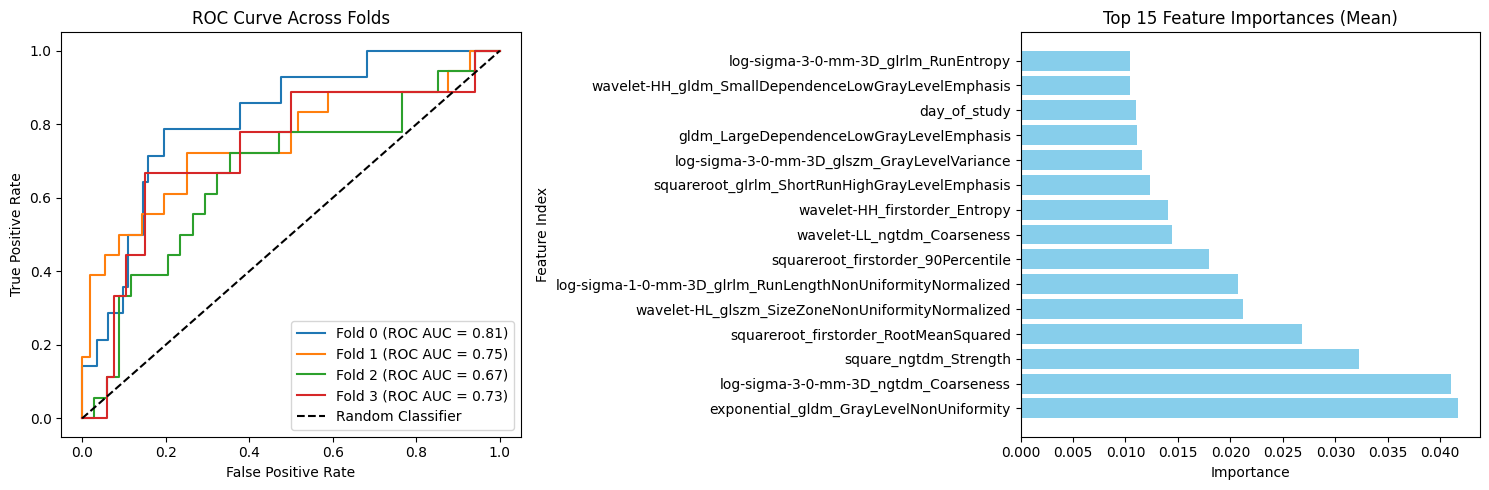


Summary Across Folds:
Mean accuracy: 0.7948
Mean F1-macro: 0.6143
Mean F1-micro: 0.7948
Mean F1-weighted: 0.7721
Mean precision: 0.5424
Mean recall: 0.2996
Mean ROC AUC: 0.7401


In [ ]:
split_method, m_data = DataSplitting.split_data_population_informed(df=df, seed=SEED, n_splits=N_SPLITS, test_size=TEST_SIZE)

train_test_and_show_results(split_method=split_method, m_data=m_data, tune_hyperparameters=False, xgb_params=xgb_params)



Fold 0:
Original train class distribution: Counter({0: 124, 1: 30})
Original test class distribution: Counter({0: 48, 1: 9})


Fold 0 results:
Accuracy: 0.8596
F1-macro: 0.7361
F1-micro: 0.8596
F1-weighted: 0.8596
Precision: 0.5556
Recall: 0.5556
ROC AUC: 0.7338
True Positives: 5, False Negatives: 4, False Positives: 4, True Negatives: 44
Classification report:
              precision    recall  f1-score   support

           0       0.92      0.92      0.92        48
           1       0.56      0.56      0.56         9

    accuracy                           0.86        57
   macro avg       0.74      0.74      0.74        57
weighted avg       0.86      0.86      0.86        57

--------------------------------------------------

Fold 1:
Original train class distribution: Counter({0: 168, 1: 39})
Original test class distribution: Counter({0: 48, 1: 9})


Fold 1 results:
Accuracy: 0.8421
F1-macro: 0.6093
F1-micro: 0.8421
F1-weighted: 0.8156
Precision: 0.5000
Recall: 0.2222
ROC AUC: 

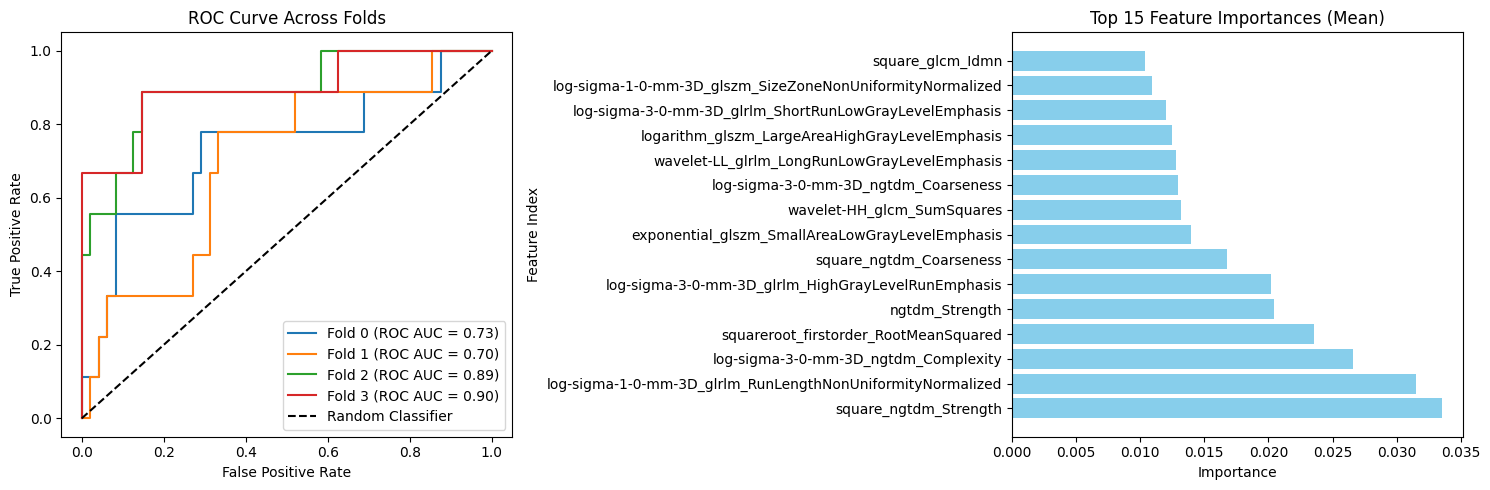


Summary Across Folds:
Mean accuracy: 0.8772
Mean F1-macro: 0.7122
Mean F1-micro: 0.8772
Mean F1-weighted: 0.8611
Mean precision: 0.7639
Mean recall: 0.3889
Mean ROC AUC: 0.8056


In [ ]:
split_method, m_data = DataSplitting.expanding_window_split_by_mice_group(df=df, n_splits=N_SPLITS)

train_test_and_show_results(split_method=split_method, m_data=m_data, tune_hyperparameters=False, xgb_params=xgb_params)

In [ ]:
split_method, m_data = DataSplitting.grouped_combinations_split_with_sampling(df=df, n_splits=N_SPLITS, sample_size=3060, seed=SEED)
print(f"Generated {len(m_data)} sampled combinations.")

train_test_and_show_results(split_method=split_method, m_data=m_data, tune_hyperparameters=False, xgb_params=xgb_params, show_label=False)

Total possible combinations: 3060
Generated 3060 sampled combinations.

Fold 0:
Original train class distribution: Counter({0: 301, 1: 29})
Original test class distribution: Counter({1: 37, 0: 15})


Fold 0 results:
Accuracy: 0.3654
F1-macro: 0.3458
F1-micro: 0.3654
F1-weighted: 0.2979
Precision: 0.8333
Recall: 0.1351
ROC AUC: 0.6414
True Positives: 5, False Negatives: 32, False Positives: 1, True Negatives: 14
Classification report:
              precision    recall  f1-score   support

           0       0.30      0.93      0.46        15
           1       0.83      0.14      0.23        37

    accuracy                           0.37        52
   macro avg       0.57      0.53      0.35        52
weighted avg       0.68      0.37      0.30        52

--------------------------------------------------

Fold 1:
Original train class distribution: Counter({0: 212, 1: 66})
Original test class distribution: Counter({0: 104})


Fold 1 results:
Accuracy: 0.7596
F1-macro: 0.4317
F1-micro: 0

KeyboardInterrupt: 

In [ ]:
# Import necessary library
import pandas as pd

# Define the feature importance lists for each split
feature_importances = {
    "grouped_combinations_split_with_sampling": {
        "exponential_glszm_SizeZoneNonUniformity": 0.0293,
        "log-sigma-3-0-mm-3D_ngtdm_Coarseness": 0.0241,
        "exponential_gldm_GrayLevelNonUniformity": 0.0178,
        "exponential_glrlm_GrayLevelNonUniformity": 0.0166,
        "log-sigma-3-0-mm-3D_glrlm_RunEntropy": 0.0117,
        "wavelet-HL_glszm_ZoneEntropy": 0.0107,
        "squareroot_firstorder_Median": 0.0103,
        "log-sigma-3-0-mm-3D_gldm_SmallDependenceHighGrayLevelEmphasis": 0.0100,
        "square_firstorder_Median": 0.0093,
        "log-sigma-1-0-mm-3D_glrlm_RunLengthNonUniformityNormalized": 0.0092,
        "wavelet-HL_glszm_SizeZoneNonUniformityNormalized": 0.0089,
        "day_of_study": 0.0088,
        "log-sigma-3-0-mm-3D_glszm_ZoneEntropy": 0.0087,
        "squareroot_firstorder_RootMeanSquared": 0.0082,
        "wavelet-HH_glcm_SumSquares": 0.0073,
    },
    "expanding_window_split": {
        "wavelet-HL_glszm_SizeZoneNonUniformityNormalized": 0.0232,
        "square_glszm_ZoneVariance": 0.0222,
        "logarithm_firstorder_RootMeanSquared": 0.0212,
        "gldm_LargeDependenceLowGrayLevelEmphasis": 0.0189,
        "log-sigma-1-0-mm-3D_ngtdm_Strength": 0.0182,
        "square_ngtdm_Strength": 0.0177,
        "gradient_firstorder_10Percentile": 0.0174,
        "log-sigma-3-0-mm-3D_ngtdm_Strength": 0.0172,
        "log-sigma-2-0-mm-3D_firstorder_Minimum": 0.0171,
        "exponential_gldm_LargeDependenceLowGrayLevelEmphasis": 0.0163,
        "wavelet-HL_glszm_SmallAreaLowGrayLevelEmphasis": 0.0160,
        "wavelet-HL_glrlm_ShortRunEmphasis": 0.0155,
        "wavelet-LH_glrlm_ShortRunEmphasis": 0.0150,
        "log-sigma-2-0-mm-3D_glszm_ZoneEntropy": 0.0129,
        "wavelet-HL_gldm_DependenceVariance": 0.0129,
    },
    "split_data_population_informed": {
        "exponential_gldm_GrayLevelNonUniformity": 0.0417,
        "log-sigma-3-0-mm-3D_ngtdm_Coarseness": 0.0411,
        "square_ngtdm_Strength": 0.0322,
        "squareroot_firstorder_RootMeanSquared": 0.0268,
        "wavelet-HL_glszm_SizeZoneNonUniformityNormalized": 0.0212,
        "log-sigma-1-0-mm-3D_glrlm_RunLengthNonUniformityNormalized": 0.0207,
        "squareroot_firstorder_90Percentile": 0.0180,
        "wavelet-LL_ngtdm_Coarseness": 0.0144,
        "wavelet-HH_firstorder_Entropy": 0.0141,
        "squareroot_glrlm_ShortRunHighGrayLevelEmphasis": 0.0124,
        "log-sigma-3-0-mm-3D_glszm_GrayLevelVariance": 0.0116,
        "gldm_LargeDependenceLowGrayLevelEmphasis": 0.0111,
        "day_of_study": 0.0110,
        "wavelet-HH_gldm_SmallDependenceLowGrayLevelEmphasis": 0.0105,
        "log-sigma-3-0-mm-3D_glrlm_RunEntropy": 0.0104,
    },
    "expanding_window_split_by_mice_group": {
        "square_ngtdm_Strength": 0.0335,
        "log-sigma-1-0-mm-3D_glrlm_RunLengthNonUniformityNormalized": 0.0315,
        "log-sigma-3-0-mm-3D_ngtdm_Complexity": 0.0266,
        "squareroot_firstorder_RootMeanSquared": 0.0236,
        "ngtdm_Strength": 0.0204,
        "log-sigma-3-0-mm-3D_glrlm_HighGrayLevelRunEmphasis": 0.0202,
        "square_ngtdm_Coarseness": 0.0168,
        "exponential_glszm_SmallAreaLowGrayLevelEmphasis": 0.0140,
        "wavelet-HH_glcm_SumSquares": 0.0132,
        "log-sigma-3-0-mm-3D_ngtdm_Coarseness": 0.0130,
        "wavelet-LL_glrlm_LongRunLowGrayLevelEmphasis": 0.0128,
        "logarithm_glszm_LargeAreaHighGrayLevelEmphasis": 0.0125,
        "log-sigma-3-0-mm-3D_glrlm_ShortRunLowGrayLevelEmphasis": 0.0120,
        "log-sigma-1-0-mm-3D_glszm_SizeZoneNonUniformityNormalized": 0.0109,
        "square_glcm_Idmn": 0.0103,
    },
}

# Combine all feature importance values into a single DataFrame
all_features = []
for split_name, features in feature_importances.items():
    for feature, importance in features.items():
        all_features.append({"Feature": feature, "Importance": importance, "Split": split_name})

# Create DataFrame and calculate mean importance for each feature
df = pd.DataFrame(all_features)
mean_importances = df.groupby("Feature")["Importance"].mean().reset_index()

# Sort features by mean importance in descending order
sorted_features = mean_importances.sort_values(by="Importance", ascending=False)

# Save the sorted features to a CSV file
sorted_features.to_csv("sorted_features.csv", index=False)
